# 📊 Day 28: Exploratory Data Analysis (EDA) – Part 2

## Hands-On EDA Notebook

**Dataset:** Titanic 

**Objective:** Perform a complete basic EDA workflow on a real-world dataset.

---
### Instructions
1. Download the kaggle dataset provided 
2. Place it in the same folder as this notebook
3. Run cells sequentially


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

## Load Dataset

In [3]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Last Few Rows

In [4]:
df.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


## Dataset Shape

In [5]:
df.shape

(418, 11)

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## Summary Statistics

In [7]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Missing Values

In [8]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## Separate Numerical and Categorical Columns

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols, categorical_cols

(Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object'),
 Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object'))

### Plot data distributions for numerical columns (histograms, boxplots)

## Histograms for Numerical Features

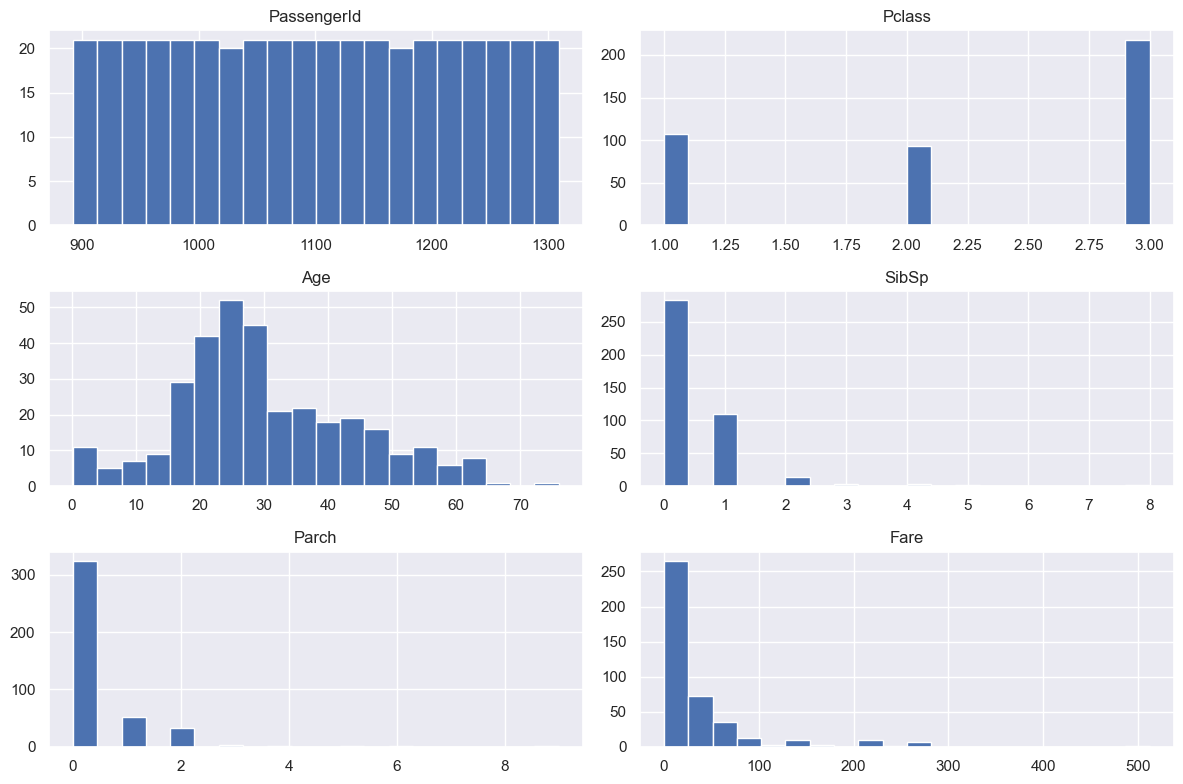

In [10]:
df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## Boxplots for Numerical Features

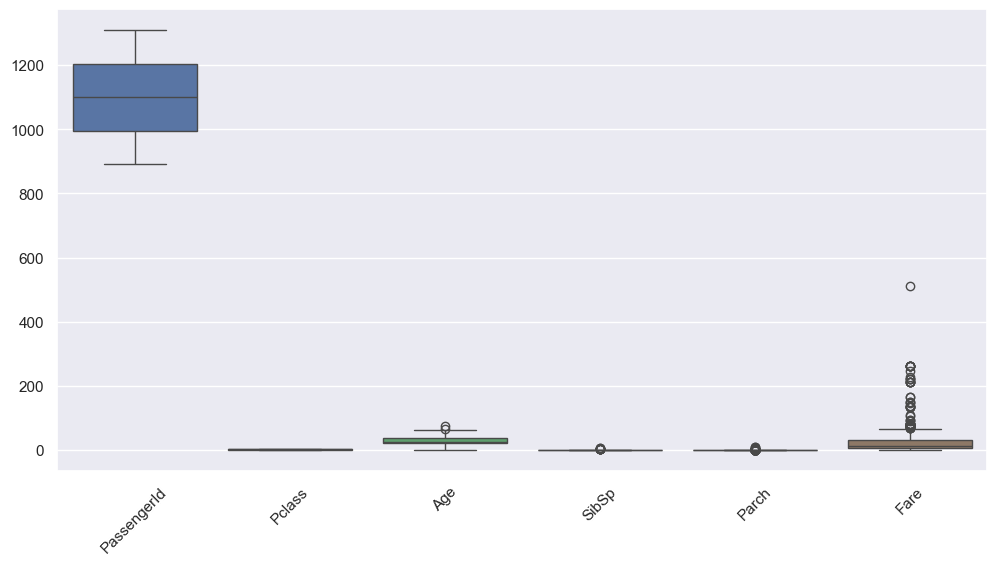

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.show()

## Categorical Feature Analysis

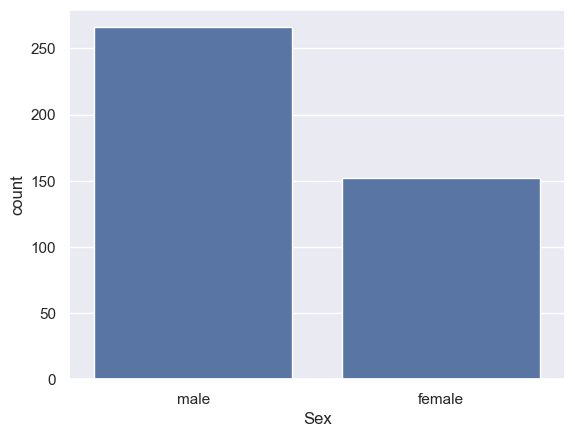

In [12]:
sns.countplot(x='Sex', data=df)
plt.show()

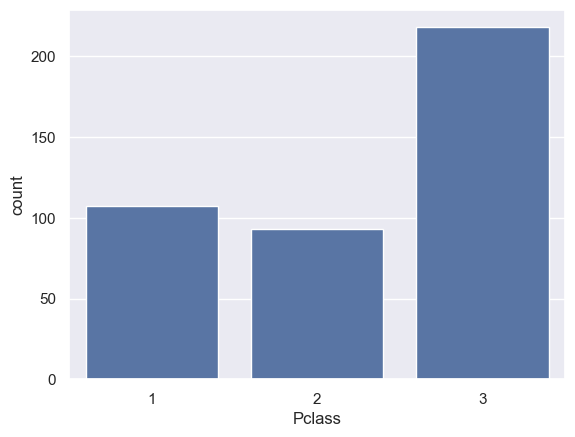

In [13]:
sns.countplot(x='Pclass', data=df)
plt.show()

## Relationship with Target Variable

In [14]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


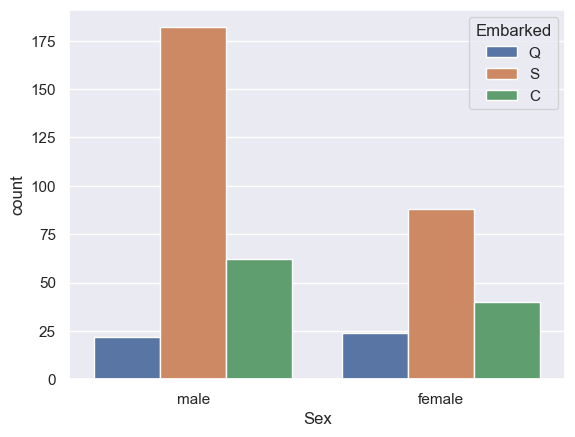

In [15]:
sns.countplot(x='Sex', hue='Embarked', data=df)
plt.show()

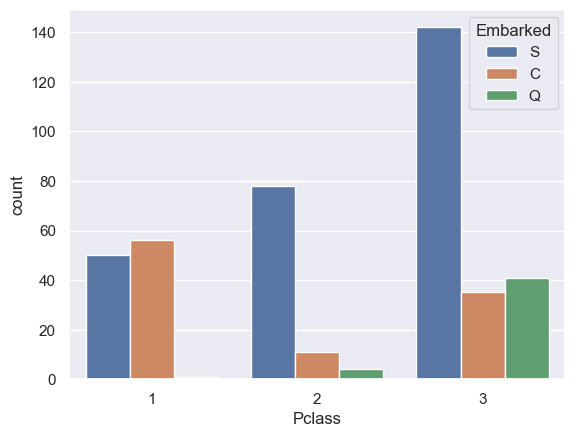

In [16]:
sns.countplot(x='Pclass', hue='Embarked', data=df)
plt.show()

## SOME EXTRA PROBLEM STATEMENT FOR MORE ANALYSIS

## For each class, find mean, min, max fare

In [17]:
df.groupby("Pclass")["Fare"].agg(["mean", "min", "max"])

,mean,min,max
Pclass,,,
1,94.280297,0.0000,512.3292
2,22.202104,9.6875,73.5000
3,12.459678,3.1708,69.5500


## What % of data belongs to top category?

In [18]:
df["Sex"].value_counts(normalize=True) * 100

Sex
male      63.636364
female    36.363636
Name: proportion, dtype: float64

## Compare histogram and boxplot of Age (Do both tell same story?)

<Axes: xlabel='Age'>

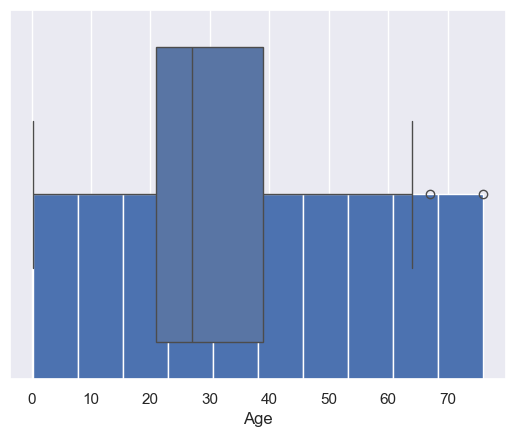

In [19]:
df["Age"].hist()
sns.boxplot(x=df["Age"])

## What is average fare for people older than 30?

In [20]:
df[df["Age"] > 30]["Fare"].mean()

61.493670229007634

## What is the Average fare by class AND gender

In [21]:
df.groupby(["Pclass", "Sex"])["Fare"].mean()

Pclass  Sex   
1       female    115.591168
        male       75.586551
2       female     26.438750
        male       20.184654
3       female     13.735129
        male       11.826350
Name: Fare, dtype: float64

## Show top 5 highest fares

In [22]:
df.sort_values(by="Fare", ascending=False).head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
343,1235,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C
53,945,1,"Fortune, Miss. Ethel Flora",female,28.0,3,2,19950,263.0000,C23 C25 C27,S
69,961,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S
24,916,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C
142,1034,1,"Ryerson, Mr. Arthur Larned",male,61.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C


## Check Which features are related? (Future concept)

In [24]:
#df.corr()

In [ ]:
sns.heatmap(df.corr(), annot=True)

## Which category appears very less?

In [ ]:
df["Embarked"].value_counts()

## What is the range of Age?

In [ ]:
df["Age"].max() - df["Age"].min()

## Are there unrealistic values? like age <0 fare <0 

In [ ]:
df[df["Age"] < 1]
df[df["Fare"] == 0]
